In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


# Cluster Profiling & Financial Persona Decoding

## 1. Theoretical Framework: Multivariate Profiling

In this final analytical stage, we bridge the gap between unsupervised machine learning and business intelligence through **Inverse Space Mapping**. While clustering was conducted in the PCA-reduced latent space $\mathbb{R}^2$ to optimize separation, we must now project these labels back onto the original feature space $\mathbb{R}^{17}$ to interpret the results.

### 1.1. Centroid Vector Definition
Each identified cluster $j$ is mathematically represented by its **Centroid Vector** $\vec{\mu}_j$. This vector serves as the statistical "signature" of the group, consisting of the arithmetic means of all financial metrics for its members:

$$\vec{\mu}_j = \begin{bmatrix} \bar{x}_{j,1} & \bar{x}_{j,2} & \dots & \bar{x}_{j,17} \end{bmatrix}$$

The components of this vector are calculated as:
$$\bar{x}_{j,f} = \frac{1}{N_j} \sum_{i \in C_j} x_{i,f}$$

### 1.2. Statistical Significance & Key Drivers
To define actionable **Business Personas**, we evaluate the deviation of each cluster centroid $\vec{\mu}_j$ from the global population mean $\vec{\mu}_{global}$. 

A financial feature $f$ is identified as a **Key Driver** for a segment if its relative magnitude significantly outweighs the norm. This multivariate analysis allows us to validate the economic significance of our segments and ensure they represent distinct consumer behaviors rather than mathematical artifacts.

In [13]:
df_raw = pd.read_csv('CC GENERAL.csv')

df_raw = df_raw.drop('CUST_ID', axis=1)
df_raw['MINIMUM_PAYMENTS'] = df_raw['MINIMUM_PAYMENTS'].fillna(df_raw['MINIMUM_PAYMENTS'].median())
df_raw['CREDIT_LIMIT'] = df_raw['CREDIT_LIMIT'].fillna(df_raw['CREDIT_LIMIT'].median())

df_clusters = pd.read_csv('data_with_clusters.csv')
df_raw['Cluster'] = df_clusters['Cluster']

df_raw['Cluster'] = df_clusters['Cluster']

## 2. Computing Cluster Signatures
We calculate the matrix of centroids $M \in \mathbb{R}^{k \times 17}$. This matrix allows us to observe the "average behavior" of each customer segment across all recorded financial dimensions.

Cluster,0,1,2,3
BALANCE,3299.125483,2156.007805,1244.262914,239.876043
BALANCE_FREQUENCY,0.977764,0.907958,0.973123,0.699442
PURCHASES,1315.103466,30.021413,2464.901072,389.056480
ONEOFF_PURCHASES,839.406799,27.388959,1471.678140,167.591884
INSTALLMENTS_PURCHASES,475.958624,2.682710,993.532081,222.014085
CASH_ADVANCE,2372.870560,1982.458332,51.677347,31.249257
PURCHASES_FREQUENCY,0.629539,0.024296,0.884053,0.482113
ONEOFF_PURCHASES_FREQUENCY,0.298466,0.018069,0.462145,0.079234
PURCHASES_INSTALLMENTS_FREQUENCY,0.422357,0.005295,0.674236,0.382470
CASH_ADVANCE_FREQUENCY,0.296906,0.281684,0.013913,0.009459


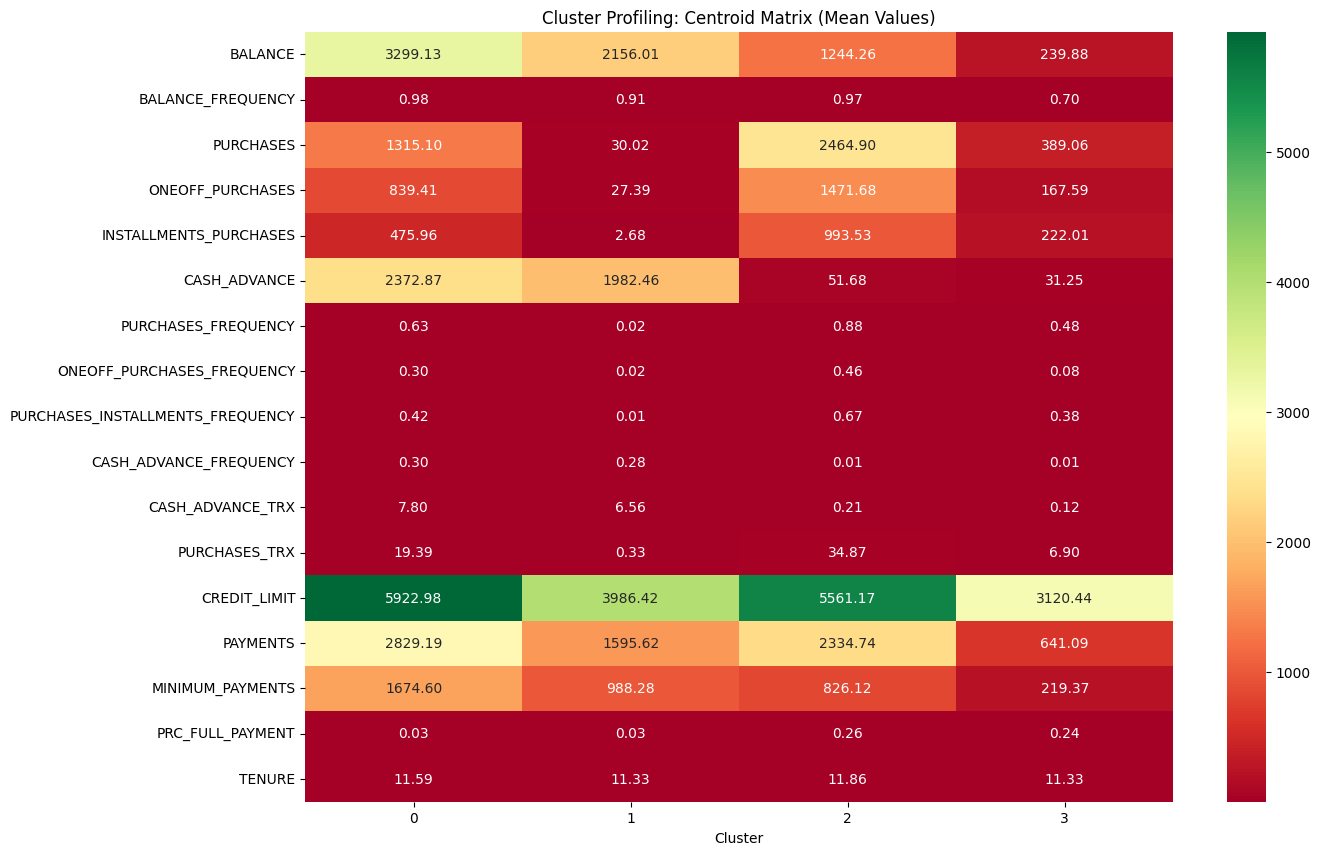

In [14]:
cluster_centroids = df_raw.groupby('Cluster').mean()

cluster_centroids_T = cluster_centroids.T

display(cluster_centroids_T)

plt.figure(figsize=(14, 10))
sns.heatmap(cluster_centroids_T, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Cluster Profiling: Centroid Matrix (Mean Values)')
plt.show()

## 3. Visualizing High-Dimensional Differences
To understand the "shape" of our clusters, we use **Radar Charts** (Spider Plots). Mathematically, this is a way to plot a multivariate vector $\vec{\mu}_j$ on a radial axis. 

Since the features have different scales (e.g., Balance vs. Tenure), we apply a **Min-Max Scaling** strictly for visualization purposes to bring all dimensions into the range $[0, 1]$.

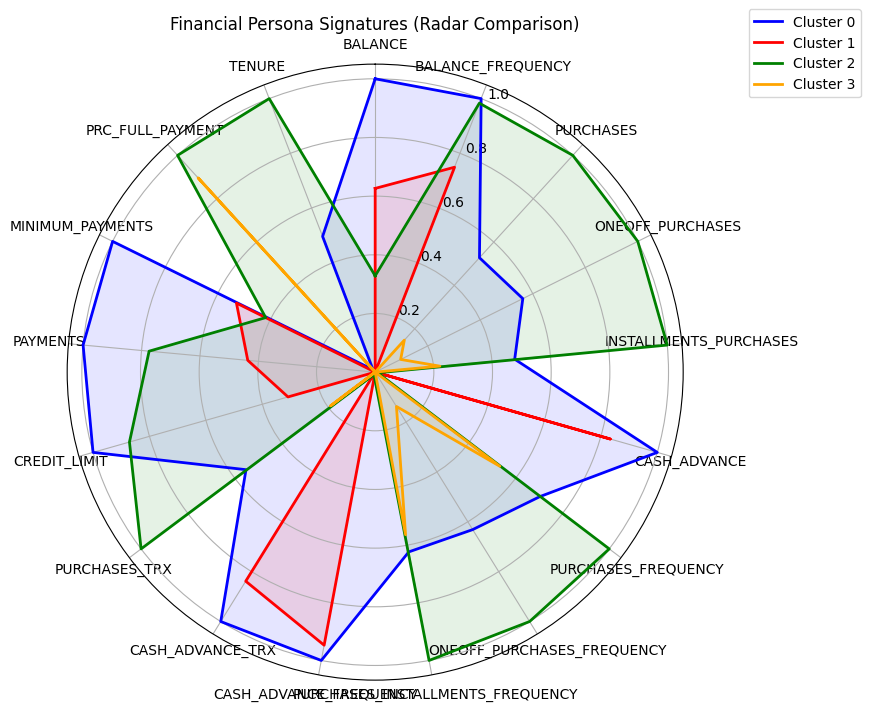

In [15]:
scaler = MinMaxScaler()
scaled_centroids = pd.DataFrame(scaler.fit_transform(cluster_centroids), 
                                columns=cluster_centroids.columns)

def plot_radar_chart(df):
    labels = df.columns
    num_vars = len(labels)
    
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] 
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    colors = ['blue', 'red', 'green', 'orange']
    
    for i in range(len(df)):
        values = df.iloc[i].tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=2, label=f'Cluster {i}')
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title('Financial Persona Signatures (Radar Comparison)')
    plt.show()

plot_radar_chart(scaled_centroids)